In [1]:
from transformers import AutoProcessor
import json

In [110]:
prompts = json.load(open("../../../curated_data/text/text_dataset/text_concept_red.json"))
vis = json.load(open("../../../activations/text/red_vis_direct_prompt.json"))
processor = AutoProcessor.from_pretrained("google/gemma-3-27b-it")

In [78]:
from circuitsvis.tokens import colored_tokens_multi
import torch



def visualize(features, prompts,n_batches, batch_size, layer,chosen_concept, start_from=0, system_prompt_token_count=0):
    pad = [0.0]*len(features[str(layer)][0][0][0])
    batched = features[str(layer)][start_from].copy()
    for i in range(start_from+1,start_from+n_batches):
        batched += features[str(layer)][i].copy()

    max_len = len(max(batched, key=lambda x: len(x)))
    for item in batched:
        if len(item)<max_len:
            for _ in range(max_len-len(item)):
                item.insert(0,pad.copy())        

    messages = [[
                    {
                        "role": "system",
                        "content": [{"type": "text", "text": f"You are a linguistics expert, your task is to identify all words that fall under the linguistic umbrella of {chosen_concept}, whether that manifests in direct words, nouns, pronouns, etc"}]
                    },
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompts[i]}
                        ]
                    }
                ] for i in range(start_from*batch_size, n_batches*batch_size+start_from*batch_size)]
    # print(list(range(start_from*batch_size, n_batches*batch_size+start_from*batch_size)), list(range(start_from+1,start_from+n_batches)))
    tokens = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True,
                    return_dict=True, return_tensors="pt", padding=True)
    str_tokens = [processor.decode(t) for t in tokens["input_ids"][:,system_prompt_token_count:].flatten(end_dim=1)]
    # Visualize activations for top 20 most prominent features
    return colored_tokens_multi(str_tokens, torch.tensor(batched, dtype=torch.float32)[:,system_prompt_token_count:,:].flatten(end_dim=1))


In [79]:
#text_concept_a_dataset_with_diverse_colors,_with_some_bias_towards_green,_some_traditionally_green_things_like_trees_perhaps
#"a dataset with diverse colors, with some bias towards green, some traditionally green things like trees perhaps"

In [80]:
vis.keys()

dict_keys(['5', '10', '15', '20', '30', '35', '40', '50', '59'])

In [159]:
rendered = visualize(features=vis.copy(), prompts=prompts.copy(), n_batches=20, batch_size=2, layer=10,chosen_concept="a dataset with diverse colors, with some bias towards red, some traditionally red things like blood perhaps", start_from=170)

In [162]:
red_features_of_interest = {5: [49540, 16776, 57482, 79500, 37005, 34061, 4880, 48407, 57752, 61469, 16929, 41, 83755, 68524, 79023, 49329, 15283, 54206, 72382, 55102, 47560, 30286, 39637, 62806, 26848, 31714, 5859, 65124, 17133, 63981, 8178, 70268, 61181], 10: [35688, 55561, 56332, 77260, 81421, 45039, 33687, 946, 40051, 11158, 31191, 13277, 13687], 15: [69605, 18504, 58121, 26259, 26972], 20: [45536, 85084, 50525, 39], 30: [60423, 2185, 1932, 16782, 75534, 72853, 59290, 3877, 46250, 69038, 50994, 52917, 13626, 11720, 6216, 23504, 30038, 73560, 76760], 35: [13965, 5263, 61200, 74900, 27052, 79021, 62769, 82227, 54462, 45506, 35523, 7113, 28110, 8784, 21206, 60504, 58713, 41310, 5477, 79598, 82163, 51956, 46332], 40: [81160, 59154, 76436, 71449, 25760, 31027, 32055, 85180, 64966, 2504, 28746, 50385, 59864, 21337, 84063, 57185, 46947, 79078, 7533, 16623, 49402, 60667], 50: [30016, 36453, 76582, 41384, 49225, 4298, 10990, 73230, 32751, 37905, 76466, 23579, 61180], 59: [29024, 33669, 22855, 11209, 5035, 37036, 64333, 74542, 58283, 34411, 67217, 69107, 67412, 16405, 42200]}
green_features_of_interest = {5: [85376, 49540, 16776, 7561, 37005, 4880, 44944, 48407, 61469, 16929, 41, 83755, 68524, 79023, 55102, 72382, 14660, 47560, 5590, 26848, 64481, 31714, 5859, 38889, 61181, 16239, 77432, 70268, 20733], 10: [23490, 58754, 75012, 54732, 58892, 33687, 49041, 10963, 36919], 15: [53473, 36556, 69605, 26972], 20: [56282, 85084, 50525], 30: [37218, 3877, 60423, 6216, 1932, 16782, 75534, 23504, 50994, 73560, 52917, 76760], 35: [42240, 5263, 61200, 55829, 24219, 58659, 27052, 62769, 26557, 54462, 11582, 41024, 7113, 63818, 53835, 68303, 8784, 14419, 45016, 41310, 12648, 40042, 79598, 82163, 51956, 46332], 40: [73866, 76436, 71449, 83357, 21792, 29734, 71855, 32055, 64966, 2504, 28746, 60877, 50385, 52689, 25180, 84063, 57185, 85993, 56941, 16623, 26106, 60667], 50: [36453, 76582, 49225, 4298, 22734, 47726, 32751, 37905, 73230, 43603, 27870], 59: [29024, 33669, 52702, 7, 22855, 11209, 5035, 7212, 64333, 74542, 67217, 67412, 2904, 81854]}
blue_features_of_interest = {5: [49540, 49797, 7561, 37005, 4880, 44944, 48407, 45337, 61469, 41, 79023, 55102, 14660, 62806, 26848, 31714, 5859, 38889, 61181], 10: [35688, 68777, 31149, 26704, 13427, 10963, 28022, 33687], 15: [7041, 26259, 887, 66616, 13305], 20: [59377, 85084, 69782], 30: [3877, 60423, 11720, 6216, 1932, 16782, 23504, 43921, 50994, 52917, 16982, 76760, 73560, 13626, 17406], 35: [82314, 13965, 5263, 61200, 24219, 33828, 27052, 62769, 3260, 12349, 54462, 26557, 7113, 7115, 8784, 45016, 58713, 41310, 39655, 68202, 79598, 82163, 46835, 51956], 40: [38400, 43393, 75522, 18829, 76436, 74774, 29719, 28826, 21792, 25760, 30633, 64966, 2504, 28746, 50385, 25180, 29534, 84063, 57185, 85993, 56941, 5490, 21747, 26106, 60667], 50: [30016, 23299, 36453, 80742, 80838, 22734, 10990, 73230, 76466, 9751, 40506, 61180, 27870], 59: [29024, 20992, 22855, 11209, 74542, 67412, 16405]}

In [164]:
image_blue= {5: [37802], 10: [59487], 15: [51322, 1154], 20: [63641, 23194, 43799], 30: [16246, 34836, 16782], 35: [54146, 29219], 40: [50429, 30158], 50: [49225], 59: [46508]} 
image_green={5: [49540, 3976, 16776, 37005, 45456, 44944, 4880, 5651, 48407, 61469, 16929, 37802, 83755, 68524, 10287, 79023, 42168, 25530, 55102, 72382, 14660, 3911, 47560, 26848, 31714, 32870, 10728, 36597, 70268, 61181], 10: [25603, 34948, 34821, 50563, 74247, 75529, 54419, 39828, 75286, 43034, 29726, 54583, 23744, 64966, 57031, 30412, 58831, 976, 84051, 27225, 44250, 39132, 37213, 59487, 62944, 62051, 63206, 48878, 17264, 67318, 72441, 8703], 15: [53889, 1154, 19076, 64132, 30216, 651, 3085, 3985, 38420, 19092, 29589, 36501, 58905, 18842, 14874, 60962, 28455, 77996, 24115, 25145, 46138, 79034, 62, 66113, 10433, 8774, 58832, 72289, 55913, 64750, 43374, 65525, 51322, 65531], 20: [35585, 29699, 39302, 35981, 62479, 37525, 43799, 28056, 63641, 16293, 35759, 20400, 14137, 83515, 23995, 41533, 20416, 55752, 56282, 61024, 38505, 32105, 12907, 72172, 42484, 38910], 30: [19081, 1932, 16782, 16654, 17681, 59538, 28051, 34836, 22548, 60562, 59290, 58908, 75165, 1567, 65574, 61613, 37806, 49455, 10031, 46005, 13111, 13626, 37218, 80868, 38760, 40173, 71406, 63861, 16246, 33528, 72571], 35: [54146, 60421, 23694, 8724, 14485, 71447, 8604, 30493, 29219, 21413, 69671, 31281, 28978, 24633, 32063, 19903, 33090, 55509, 32984, 15195, 41310, 12780, 22892, 74363, 46332, 6270], 40: [81160, 51209, 73741, 12301, 18551, 45595, 16924, 33443, 12710, 79662, 56024, 51032, 47321, 13275, 16998, 14827, 7533, 45423, 51189, 6390, 32501, 50429], 50: [62469, 76681, 27657, 10509, 37905, 70804, 78102, 38935, 59678, 57000, 68139, 62635, 61491, 42302, 49225, 22734, 62544, 27870, 36453, 13417, 47726, 72943, 19444, 60926, 44159], 59: [33027, 27015, 18960, 58265, 42147, 46508, 59565, 39214, 65202, 26554, 36796, 78525, 55741, 20551, 61008, 36691, 6995, 8792, 77546, 66027, 37106, 77816]} 
image_red = {5: [42168, 37802], 10: [29726, 59487, 57031], 15: [66113, 55913, 64750, 77112, 25145], 20: [35585, 16293], 30: [37218, 13626, 46005], 35: [30493, 72198], 40: [50429], 50: [62635], 59: [79990, 77546, 33574]}

In [165]:
image_data = {
    "red": image_red,
    "green": image_green,
    "blue": image_blue
}

text_data = {
    "red": red_features_of_interest,
    "green": green_features_of_interest,
    "blue": blue_features_of_interest
}

overlaps = {}

for color in image_data:
    overlaps[color] = {}

    for key in image_data[color]:
        image_vals = set(image_data[color].get(key, []))
        text_vals = set(text_data[color].get(key, []))

        common = sorted(image_vals.intersection(text_vals))

        if common:
            overlaps[color][key] = common

print(overlaps)

{'red': {30: [13626]}, 'green': {5: [4880, 14660, 16776, 16929, 26848, 31714, 37005, 44944, 47560, 48407, 49540, 55102, 61181, 61469, 68524, 70268, 72382, 79023, 83755], 20: [56282], 30: [1932, 16782, 37218], 35: [41310, 46332], 50: [22734, 27870, 36453, 37905, 47726, 49225]}, 'blue': {30: [16782]}}


In [148]:
green = {5:[],10: [0, 2, 3, 4, 6, 8], 15:[],20: [1], 30: [9], 35: [2, 10, 11, 13, 15, 16, 20], 40: [0, 2, 4, 6, 9, 11, 13, 14, 15, 17, 18, 19, 20, 21], 50:[], 59:[]}
blue = {5:[1,13,16], 10:[3,4,6], 15:[0,3], 20:[0,1,2], 30:[7,10,12], 35:[3,5,8,13,14], 40:[0,12,20,22,23], 50:[9], 59:[]}
red = {5:[15,16,17,23,26], 10:[1,2,3,4,5,7,9,10,11,12], 15:[1,2,3], 20:[0,1,3], 30: [8, 17], 35: [2, 3, 5, 7, 9, 10, 12, 13, 14, 15, 16], 40:[12], 50: [6], 59:[]}

In [ ]:

green_feats = {key:[green_features_of_interest[key][index] for index in green[key]] for key in green.keys()}
red_feats = {key:[blue_features_of_interest[key][index] for index in blue[key]] for key in blue.keys()}
blue_feats = {key:[red_features_of_interest[key][index] for index in red[key]] for key in red.keys()}

In [154]:
with open("../../../feats/green.json", "w") as f:
    json.dump(green_feats, f)

In [155]:
with open("../../../feats/blue.json", "w") as f:
    json.dump(blue_feats, f)

In [156]:
with open("../../../feats/red.json", "w") as f:
    json.dump(red_feats, f)

In [ ]:
# These appear in the order that they appear in features of interest
#Green v2
#layer 20 feat 9
#layer 35 feat 9 
#layer 50 feat 17

#Blue v1
#layer 5 feat 1, 13, 16
#layer 10 feat 3, 4, 6
#layer 15 feat 0, 3
#layer 20 feat 0, 1, 2
#layer 30 feat 7, 10, 12
#layer 35 feat 3, 5, 8, 13, 14
#layer 40 feat 0, 12, 20, 22, 23
#layer 50 feat 9

#Red v1
#layer 5 feat 15, 16, 17, 23, 26
#layer 10 feat 1, 2, 3, 4, 5, 7, 9, 10, 11, 12
#layer 15 feat 1, 2, 3
#layer 20 feat (0, 1:colors), 3
#layer 40 feat 12



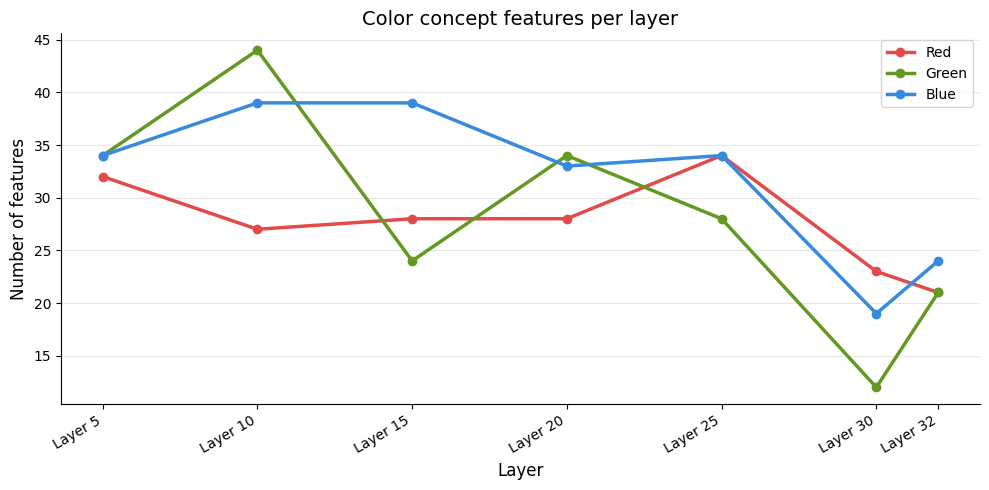

Saved: color_features_plot_v2.png


In [1]:
import matplotlib.pyplot as plt

layers = [5, 10, 15, 20, 25, 30, 32]

red = {
    "5":  [20737, 24706, 39554, 39300, 31370, 34188, 51985, 3729, 36632, 60064, 35617, 21796, 4645, 28205, 44078, 13744, 49328, 40376, 57272, 19265, 49474, 20292, 61509, 4422, 13898, 54748, 13917, 734, 24697, 996, 51703, 36985],
    "10": [38535, 37129, 57359, 46736, 63635, 52503, 55835, 16545, 19492, 38056, 5688, 55481, 21691, 11457, 5190, 11259, 30546, 43480, 43353, 30686, 37598, 6112, 14182, 42732, 8430, 9973, 2427],
    "15": [8962, 34311, 32277, 24857, 37921, 35619, 17705, 63793, 23985, 4531, 16180, 18998, 38586, 38592, 34503, 65351, 56650, 7758, 22864, 59604, 63188, 12504, 56281, 42595, 17127, 34936, 52220, 18175],
    "20": [30467, 65032, 49680, 38418, 13078, 45591, 7576, 45849, 63398, 61991, 9258, 7084, 41008, 33078, 5944, 1464, 45389, 62288, 47186, 24419, 28645, 49894, 38120, 44776, 29930, 60782, 58351, 2929],
    "25": [22147, 40708, 2570, 56208, 28821, 27670, 53528, 6048, 7461, 49191, 8618, 15660, 20781, 29744, 2354, 60083, 50612, 17078, 37177, 23995, 6848, 56385, 1611, 21451, 14289, 33502, 39778, 21092, 53483, 2799, 23408, 10223, 49018, 12030],
    "30": [55041, 2946, 31753, 2579, 2709, 16533, 45975, 57239, 53279, 40486, 48681, 64043, 30145, 48453, 8903, 59978, 55883, 53079, 4191, 31201, 30698, 56442, 39803],
    "32": [51334, 35082, 61067, 15884, 47374, 8229, 63525, 21671, 26534, 49717, 4668, 40514, 46534, 14930, 42842, 5468, 608, 18026, 50416, 58867, 16378],
}

blue = {
    "5":  [39300, 26374, 17672, 10378, 51985, 8982, 18074, 31904, 4645, 48295, 46760, 4018, 35891, 63925, 37430, 14265, 23227, 51644, 45505, 46403, 20292, 56262, 8263, 13898, 33483, 44372, 51541, 42215, 31847, 20075, 19437, 42227, 59385, 18042],
    "10": [32642, 4356, 55172, 30471, 56331, 15760, 42004, 44702, 50080, 16545, 22306, 50081, 52390, 12076, 31660, 64050, 55481, 54465, 22852, 11259, 61262, 47694, 20816, 57813, 5846, 33495, 45016, 34395, 25439, 30559, 18785, 6626, 6112, 23527, 50031, 49909, 13304, 26491, 1404],
    "15": [42880, 8962, 34311, 59017, 4370, 24857, 2331, 34936, 43036, 20765, 17705, 63793, 4531, 16180, 38326, 38200, 49465, 16957, 29118, 38592, 21447, 21192, 21324, 7758, 22864, 59604, 55894, 12504, 56281, 38882, 42595, 17127, 42215, 11116, 53106, 58488, 6522, 9211, 50296],
    "20": [30467, 12036, 32525, 48401, 38418, 2707, 47251, 18833, 13078, 45591, 39321, 42275, 39843, 63398, 61991, 35755, 7084, 41008, 1464, 17082, 56897, 58820, 31815, 36686, 3280, 21342, 24420, 44776, 29930, 60782, 58351, 36340, 64895],
    "25": [12294, 33938, 16530, 1555, 7461, 58025, 49577, 15660, 38188, 38062, 57136, 3252, 44343, 56385, 33859, 54342, 57287, 51656, 38858, 12622, 62424, 861, 52317, 35295, 29929, 20970, 25323, 23020, 30828, 13806, 3312, 63219, 40443, 10367],
    "30": [22529, 31753, 25742, 39186, 45975, 4650, 9644, 1718, 63031, 24760, 63304, 11218, 4191, 1514, 30698, 35311, 23537, 45170, 56442],
    "32": [51334, 15878, 7817, 33418, 61067, 13, 55191, 64411, 32283, 24479, 20780, 27825, 4668, 27213, 59086, 49237, 37589, 42842, 5468, 61663, 8929, 26474, 58867, 15732],
}

green = {
    "5":  [20737, 34188, 34447, 51985, 46613, 18074, 21796, 4645, 20393, 44078, 64305, 62643, 33332, 59061, 16438, 20919, 58942, 24132, 20292, 64456, 13898, 49738, 6988, 21708, 30037, 42722, 16484, 35813, 27753, 52204, 45679, 14449, 32760, 24697],
    "10": [11649, 41346, 37507, 65164, 46093, 15760, 37777, 42004, 42647, 280, 36000, 42530, 44069, 302, 1970, 54198, 51512, 55481, 23610, 25275, 46268, 55229, 48317, 42181, 15306, 47694, 30931, 13780, 33495, 16343, 35930, 14177, 24161, 30563, 14948, 56165, 23142, 53094, 55787, 19565, 5998, 29423, 49400, 18430],
    "15": [42880, 8962, 34950, 34311, 4370, 24857, 34936, 17705, 15152, 63793, 4531, 16180, 38326, 49465, 7758, 22864, 59604, 63188, 12504, 56281, 17127, 60914, 58488, 50296],
    "20": [30467, 65032, 32654, 48401, 27025, 30612, 13078, 45591, 60952, 45849, 45721, 39321, 7576, 63398, 58792, 35755, 7084, 41008, 1464, 8901, 31815, 36686, 30802, 31961, 44776, 38120, 60782, 45424, 2929, 36340, 11637, 54646, 39674, 39422],
    "25": [16788, 278, 7461, 38310, 15660, 40375, 8504, 6848, 56385, 60228, 31557, 34760, 62024, 22987, 1997, 12622, 9679, 27992, 861, 6499, 21092, 20970, 50283, 60910, 3312, 371, 40443, 10367],
    "30": [51075, 10659, 40486, 31753, 38506, 12784, 45689, 45170, 35670, 47289, 62906, 9532],
    "32": [13058, 38408, 33418, 61067, 13, 18849, 58019, 20780, 62389, 57914, 2253, 59086, 46415, 58193, 14930, 49237, 41941, 5468, 52190, 34156, 58867],
}

def count_features(color_dict, layers):
    return [len(color_dict.get(str(l), [])) for l in layers]

red_counts   = count_features(red, layers)
green_counts = count_features(green, layers)
blue_counts  = count_features(blue, layers)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(layers, red_counts,   color='#E24B4A', marker='o', linewidth=2.5, markersize=6, label='Red')
ax.plot(layers, green_counts, color='#639922', marker='o', linewidth=2.5, markersize=6, label='Green')
ax.plot(layers, blue_counts,  color='#378ADD', marker='o', linewidth=2.5, markersize=6, label='Blue')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Number of features', fontsize=12)
ax.set_title('Color concept features per layer', fontsize=14)
ax.set_xticks(layers)
ax.set_xticklabels([f'Layer {l}' for l in layers], rotation=30, ha='right')
ax.yaxis.get_major_locator().set_params(integer=True)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('color_features_plot_v2.png', dpi=150)
plt.show()
print("Saved: color_features_plot_v2.png")

In [161]:
rendered

In [133]:
t = torch.rand((2,2,7))

In [134]:
t

tensor([[[4.8790e-01, 4.8663e-01, 6.7805e-01, 5.0194e-01, 1.0234e-01,
          5.1132e-01, 2.1480e-01],
         [2.7898e-02, 4.5834e-01, 9.9581e-01, 1.9950e-03, 3.3191e-01,
          1.5282e-01, 8.6629e-01]],

        [[1.7012e-01, 6.3327e-01, 9.0860e-01, 4.4126e-01, 9.6561e-01,
          1.8259e-02, 3.8499e-01],
         [3.7074e-05, 2.5775e-01, 6.9528e-01, 7.7547e-01, 5.1927e-01,
          4.1337e-01, 5.4419e-05]]])

In [135]:
t[:,:,[6,2]]

tensor([[[2.1480e-01, 6.7805e-01],
         [8.6629e-01, 9.9581e-01]],

        [[3.8499e-01, 9.0860e-01],
         [5.4419e-05, 6.9528e-01]]])

In [3]:
with open("../../../curated_data/text/text_dataset_classified/text_concept_green_classified.json", "r") as f:
    classified = json.load(f)

In [50]:
chosen_concept = "a dataset with diverse colors, with some bias towards green, some traditionally green things like the trees perhaps"
messages = [[
                {
                    "role": "system",
                    "content": [{"type": "text", "text": f"You are a linguistics expert, your task is to identify all words that fall under the linguistic umbrella of {chosen_concept}, whether that manifests in direct words, nouns, pronouns, etc"}]
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompts[3]}
                    ]
                }
            ] ]
tokens = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True,
                return_dict=True, return_tensors="pt", padding=True)
str_tokens = [processor.decode(t) for t in tokens["input_ids"].flatten(end_dim=1)]

In [46]:
tokens

{'input_ids': tensor([[     2,    105,   2364,    107,   3048,    659,    496, 127533,   7710,
         236764,    822,   4209,    563,    531,   8701,    784,   4171,    600,
           3798,   1208,    506,  45755,  36187,    529,    496,  15297,    607,
          12801,   7913, 236764,    607,   1070,  17482,   5645,   3826, 236764,
           1070,  37155,   3826,   2432,   1133,    506,   7146,   8229, 236764,
           3363,    600,  99688,    528,   1982,   4171, 236764,  77093, 236764,
         107701, 236764,   4044,    108,  32051,    586,  16715,  26677,  11595,
          53087,    506,    861,  51179,    618,    901,  28888,   4888, 236761,
          21516,   3305,    506,   2258,    691,    496,   3103,  16627, 236764,
            840,   4534,   9312,    506,  28239,   2778,    625,   6111,    531,
            506,   8351, 236761,   2195,   6544,    531,   6727,    625,    607,
           2173,  45204,    531,   7002,    506,  12732, 236761,    106,    107,
            10

In [51]:
token_acts = vis["20"][1][1]

In [49]:
classified['3']["labels"]

{'During': '0',
 ' autumn': '0',
 ',': '0',
 ' the': '0',
 ' once': '0',
 ' vibrant': '0',
 ' green': '1',
 ' canopy': '1',
 ' transforms': '0',
 ' into': '0',
 ' a': '0',
 ' sea': '0',
 ' of': '0',
 ' rus': '0',
 'set': '0',
 ' and': '0',
 ' gold': '0',
 '.': '0',
 ' Maple': '1',
 ' trees': '1',
 ' drop': '0',
 ' their': '0',
 ' fiery': '0',
 ' leaves': '1',
 ' blank': '0',
 'eting': '0',
 ' dark': '0',
 ' brown': '0',
 ' earth': '0',
 ' in': '0',
 ' crunchy': '0',
 ' carpet': '0',
 ' Squirrel': '0',
 's': '0',
 ' sc': '0',
 'urry': '0',
 ' about': '0',
 ' oblivious': '0',
 ' to': '0',
 ' dramatic': '0',
 ' shift': '0',
 ' landscape': '0',
 "'": '0',
 ' palette': '0'}

In [55]:
for i in [i for i in range(len(token_acts)) if str_tokens[i] in classified['3']["labels"] and classified['3']["labels"][str_tokens[i]]=="1"]:
    print(token_acts[i])

[0.05167308449745178, 0.05422084778547287, 0.0, 0.05377448722720146, 0.0, 0.0, 0.053755734115839005, 0.05498645454645157, 0.0, 0.051969513297080994, 0.05248367041349411, 0.0, 0.05284348875284195, 0.05370872840285301, 0.05396881327033043, 0.05201283097267151, 0.052806347608566284, 0.05217823386192322, 0.055660929530858994, 0.05293485149741173]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [8]:
import json
with open("../../../num_tokens_since_fired.json", "r") as f:
    bread = json.load(f)

In [9]:
len(bread["0"])

86016

In [10]:
nonzero = {i:sum(bread[i]) for i in bread.keys() if sum(bread[i])!=0}

In [11]:
len(nonzero)

2

In [12]:
max(nonzero.items(), key=lambda x: x[1])

('2', 8192)

In [7]:
nonzero

{'0': 16384,
 '1': 32768,
 '2': 8192,
 '4': 8192,
 '317': 8192,
 '352': 8192,
 '426': 8192,
 '436': 8192,
 '444': 8192,
 '453': 8192,
 '461': 8192,
 '462': 8192,
 '463': 8192,
 '470': 16384,
 '471': 16384,
 '473': 8192,
 '485': 8192,
 '487': 8192,
 '489': 8192,
 '490': 8192,
 '491': 16384,
 '492': 8192,
 '494': 8192,
 '496': 16384,
 '498': 8192,
 '500': 24576,
 '501': 49152,
 '502': 8192,
 '504': 8192,
 '506': 8192,
 '507': 8192,
 '510': 8192,
 '511': 16384,
 '519': 8192,
 '522': 8192,
 '523': 8192,
 '532': 16384,
 '533': 16384,
 '534': 8192,
 '535': 8192,
 '536': 8192,
 '537': 16384,
 '539': 8192,
 '543': 24576,
 '544': 16384,
 '547': 24576,
 '548': 16384,
 '552': 16384,
 '553': 16384,
 '556': 16384,
 '557': 8192,
 '558': 16384,
 '559': 16384,
 '560': 32768,
 '561': 65536,
 '562': 24576,
 '563': 16384,
 '564': 24576,
 '565': 8192,
 '568': 8192,
 '569': 8192,
 '570': 8192,
 '571': 16384,
 '572': 24576,
 '573': 16384,
 '574': 24576,
 '575': 8192,
 '576': 8192,
 '577': 8192,
 '578': 1638

In [96]:
sum(bread["2"])

254823

In [97]:
max(bread["2"])

3

In [98]:
max(bread["1"])

2

In [86]:
max(bread["0"])

8192

In [13]:
with open("../../../top_indices_BK_flattened.json", "r") as f:
    bread2 = json.load(f)

In [14]:
master_set = set()
for i in range(len(bread2)):
    master_set = master_set | set(bread2[i])

In [15]:
len(master_set)

86016

In [24]:
len(bread2[0])

8806400

In [25]:
8192*1075

8806400

In [31]:
len(set(bread2[4]))

86016

In [36]:
it = iter([0,1])

In [38]:
while(1):
    try:
        next(it)
    except StopIteration:
        print("done")
        break

done
